In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
import pickle as pk
import scipy as sp

from polyid_utils import Utils, Analyze

from matplotlib import pyplot as plt
from matplotlib import cm
import seaborn as sns

from sklearn.metrics import mean_absolute_error as mae

utils = Utils()
alz = Analyze()

%load_ext autoreload
%autoreload 2

2025-12-02 09:13:06.256119: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 09:13:07.556153: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-02 09:13:07.556191: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-02 09:13:07.556201: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 09:13:08.168214: I tensorflow/core/platform/cpu_feature_g

In [3]:
os.chdir("../../")
os.getcwd()

'/kfs2/projects/invpoly/jlaw/FY24_polyID_research/transfer_learning'

In [16]:
md_date = "250801"
data_md = pd.read_csv(f"data/training_data/{md_date}md_train.csv", index_col=0)
print(data_md.shape)
data_md.head(2)

(1820, 51)


,trimer_smiles,smiles_monomer,job_hash,md_density_trimer,md_rg_trimer,md_rg_trimer_norm,md_hov_trimer,md_hov_trimer_norm,md_heat_capacity_liquid,md_heat_capacity_liquid_norm,...,rdf_O-O,rdf_O-P,rdf_O-S,rdf_S-S,trimer_MW,trimer_num_atoms,replicate_structure,distribution,smiles_polymer,mechanism
0,Nc1ccc(Oc2ccc(Oc3ccc(N4C(=O)c5ccc(C(c6ccc7c(c6...,Nc1ccc(Oc2ccc(Oc3ccc(N)cc3)c(-c3ccccc3)c2)cc1....,ae1bc72eb46f46599ef09430dc6f09e9,1.294785,11.5941,0.067408,113.359602,0.659067,1.427575,0.008300,...,0.987634,NaN,NaN,NaN,2346.425182,172,0,NaN,Nc1ccc(Oc2ccc(Oc3ccc(N4C(=O)c5ccc(C(c6ccc7c(c6...,todo
1,Nc1ccc(-c2ccc(Oc3ccc([C@]4(c5ccc(Oc6ccc(-c7ccc...,O=C(O)c1cc(C(=O)O)c(C(=O)O)cc1C(=O)O.Nc1ccc(-c...,50a15b54a983bc27741ef6fa709f9d4c,1.246136,10.6209,0.044070,147.245422,0.610977,2.181953,0.009054,...,1.227732,NaN,NaN,NaN,3261.740762,241,0,NaN,Nc1ccc(-c2ccc(Oc3ccc([C@]4(c5ccc(Oc6ccc(-c7ccc...,todo


In [18]:
data_md.columns

Index(['trimer_smiles', 'smiles_monomer', 'job_hash', 'md_density_trimer',
       'md_rg_trimer', 'md_rg_trimer_norm', 'md_hov_trimer',
       'md_hov_trimer_norm', 'md_heat_capacity_liquid',
       'md_heat_capacity_liquid_norm', 'md_heat_capacity_gas',
       'md_heat_capacity_gas_norm', 'md_excess_heat_capacity_trimer',
       'md_avg_max_heavy_atom_dist', 'md_avg_max_heavy_atom_dist_norm',
       'md_avg_variance', 'md_avg_auc_fit_at_zero_cross',
       'md_average_lifetime_ps', 'total_bonds_analyzed',
       'md_avg_hbonds_per_frame', 'md_avg_hbonds_per_frame_norm', 'rdf_Br-Br',
       'rdf_Br-C', 'rdf_Br-O', 'rdf_C-C', 'rdf_C-Cl', 'rdf_C-F', 'rdf_C-N',
       'rdf_C-O', 'rdf_C-P', 'rdf_C-S', 'rdf_Cl-Cl', 'rdf_Cl-N', 'rdf_Cl-O',
       'rdf_F-F', 'rdf_F-N', 'rdf_F-O', 'rdf_N-N', 'rdf_N-O', 'rdf_N-P',
       'rdf_N-S', 'rdf_O-O', 'rdf_O-P', 'rdf_O-S', 'rdf_S-S', 'trimer_MW',
       'trimer_num_atoms', 'replicate_structure', 'distribution',
       'smiles_polymer', 'mechanism'],
   

In [ ]:
# col_groups = {'heat': ['Radius of Gyration (Angstrom)', 'Heat of Vaporization (kcal/mol)',
#        'Heat Capacity Liquid (kcal/mol*K)', 'Heat Capacity Gas (kcal/mol*K)',
#        'Excess Heat Capacity (kcal/mol*K)',],
#     'viscocity': ['Average_Variance', 'Average_AUC_fit_at_zero-cross', 'Average lifetime (ps)'],
#               'h-bonds': ['Total bonds analyzed', 'Average H-bonds per frame'],
#               'rdfs': ['Br-Br', 'Br-C',
#        'Br-O', 'C-C', 'C-Cl', 'C-F', 'C-N', 'C-O', 'C-P', 'C-S', 'Cl-Cl',
#        'Cl-N', 'Cl-O', 'F-F', 'F-N', 'F-O', 'N-N', 'N-O', 'N-P', 'N-S', 'O-O',
#        'O-P', 'O-S', 'S-S'],
#              }

In [ ]:
full_names = {
    'md_density_trimer': 'MD Density (g/cm³)',
    'md_rg_trimer': 'Radius of Gyration (Angstrom)',
    'md_hov_trimer': 'Heat of Vaporization (kcal/mol)',
    'md_heat_capacity_liquid': 'Heat Capacity Liquid (kcal/mol*K)',
    'md_heat_capacity_gas': 'Heat Capacity Gas (kcal/mol*K)',
    'md_excess_heat_capacity_trimer': 'Excess Heat Capacity (kcal/mol*K)',
    'md_avg_max_heavy_atom_dist': 'Average Max Heavy Atom Distance (Angstrom)',
    'md_avg_variance': 'Average Variance',
    'md_avg_auc_fit_at_zero_cross': 'Average AUC fit at zero-cross',
    'md_average_lifetime_ps': 'Average lifetime (ps)',
    'total_bonds_analyzed': 'Total bonds analyzed',
    'md_avg_hbonds_per_frame': 'Average H-bonds per frame',
}

In [17]:
data_md.columns

Index(['trimer_smiles', 'smiles_monomer', 'job_hash', 'md_density_trimer',
       'md_rg_trimer', 'md_rg_trimer_norm', 'md_hov_trimer',
       'md_hov_trimer_norm', 'md_heat_capacity_liquid',
       'md_heat_capacity_liquid_norm', 'md_heat_capacity_gas',
       'md_heat_capacity_gas_norm', 'md_excess_heat_capacity_trimer',
       'md_avg_max_heavy_atom_dist', 'md_avg_max_heavy_atom_dist_norm',
       'md_avg_variance', 'md_avg_auc_fit_at_zero_cross',
       'md_average_lifetime_ps', 'total_bonds_analyzed',
       'md_avg_hbonds_per_frame', 'md_avg_hbonds_per_frame_norm', 'rdf_Br-Br',
       'rdf_Br-C', 'rdf_Br-O', 'rdf_C-C', 'rdf_C-Cl', 'rdf_C-F', 'rdf_C-N',
       'rdf_C-O', 'rdf_C-P', 'rdf_C-S', 'rdf_Cl-Cl', 'rdf_Cl-N', 'rdf_Cl-O',
       'rdf_F-F', 'rdf_F-N', 'rdf_F-O', 'rdf_N-N', 'rdf_N-O', 'rdf_N-P',
       'rdf_N-S', 'rdf_O-O', 'rdf_O-P', 'rdf_O-S', 'rdf_S-S', 'trimer_MW',
       'trimer_num_atoms', 'replicate_structure', 'distribution',
       'smiles_polymer', 'mechanism'],
   

In [42]:
# see how strongly correlated the columns are with the # atoms
for c in [c for c in data_md.columns if 'md_' in c and '_norm' not in c]:
    print(c, f"{sp.stats.pearsonr(x=data_md[c].dropna(), y=data_md.loc[data_md[c].notna(), 'trimer_num_atoms'])[0]:0.3f}")

md_density_trimer 0.385
md_rg_trimer 0.868
md_hov_trimer 0.867
md_heat_capacity_liquid 0.906
md_heat_capacity_gas 0.958
md_excess_heat_capacity_trimer 0.267
md_avg_max_heavy_atom_dist 0.891
md_avg_variance -0.236
md_avg_auc_fit_at_zero_cross 0.493
md_average_lifetime_ps 0.127
md_avg_hbonds_per_frame -0.194


In [7]:
cols_to_normalize = ['md_rg_trimer',
                    'md_hov_trimer',
                    'md_heat_capacity_liquid',
                    'md_heat_capacity_gas',
                    'md_avg_max_heavy_atom_dist',
                    'md_avg_hbonds_per_frame',
                    ]

In [ ]:
# normalize by the number of atoms
for c in cols_to_normalize:
    norm_col = c + "_norm"
    data_md[norm_col] = data_md[c] / data_md.trimer_num_atoms

In [ ]:
md_cols = ['md_density_trimer', 'md_rg_trimer_norm', 'md_hov_trimer_norm',
       'md_heat_capacity_liquid_norm', 'md_heat_capacity_gas_norm',
       'md_excess_heat_capacity_trimer', 'md_avg_max_heavy_atom_dist_norm',
       'md_avg_variance', 'md_avg_auc_fit_at_zero_cross',
       'md_average_lifetime_ps', 'md_avg_hbonds_per_frame_norm']

In [38]:
# see how strongly correlated the columns are with each other
md_corr_coeffs = {}
for i, c in enumerate(md_cols):
    for j, c2 in enumerate(md_cols + ['trimer_num_atoms']):
        if i < j:
            df = data_md.dropna(subset=[c, c2])
            if len(df) > 2:
                r, p = sp.stats.pearsonr(x=df[c], y=df[c2])
                md_corr_coeffs[(c, c2)] = r
print(len(md_corr_coeffs))

66


In [39]:
strong_corr = {k: v for k, v in md_corr_coeffs.items() if v > 0.8 or v < -0.8}
strong_corr

{('md_rg_trimer_norm', 'md_hov_trimer_norm'): 0.820430041197313,
 ('md_rg_trimer_norm', 'md_avg_max_heavy_atom_dist_norm'): 0.990806787244987,
 ('md_rg_trimer_norm', 'trimer_num_atoms'): -0.8257263316464865,
 ('md_hov_trimer_norm', 'md_avg_max_heavy_atom_dist_norm'): 0.8174268810599813,
 ('md_hov_trimer_norm', 'trimer_num_atoms'): -0.8109024857292327,
 ('md_heat_capacity_liquid_norm',
  'md_heat_capacity_gas_norm'): 0.8468063467339302,
 ('md_avg_max_heavy_atom_dist_norm', 'trimer_num_atoms'): -0.8270624306868855}

## Calculate correlations between MD properties and with polymer properties

In [23]:
db_date = "250121"
loc_training_data = Path(f"data/training_data/{db_date}db_pub_{md_date}md_and_exp_train.csv")
print(loc_training_data)
data_merged = pd.read_csv(loc_training_data)
print(len(data_merged))

data/training_data/250121db_pub_250801md_and_exp_train.csv
1507


In [26]:
data_merged.columns

Index(['Unnamed: 0', 'hash-monomers-distribution', 'monomers', 'distribution',
       'mechanism', 'Glass_Transition', 'Melt_Temp', 'Cp_solid_slope',
       'Cp_solid_intercept', 'Cp_liquid_slope', 'Cp_liquid_intercept',
       'log10_ElongBreak', 'YoungMod', 'Tensile_Strength', 'Density',
       'log10_Permeability_CH4', 'log10_Permeability_CO2',
       'log10_Permeability_N2', 'log10_Permeability_O2',
       'log10_Permeability_H2', 'log10_Permeability_H2O', 'smiles_polymer',
       'hash-smiles_polymer', 'smiles_monomer', 'replicate_structure',
       'md_density_trimer', 'md_rg_trimer_norm', 'md_hov_trimer_norm',
       'md_heat_capacity_liquid_norm', 'md_heat_capacity_gas_norm',
       'md_excess_heat_capacity_trimer', 'md_avg_max_heavy_atom_dist_norm',
       'md_avg_variance', 'md_avg_auc_fit_at_zero_cross',
       'md_average_lifetime_ps', 'md_avg_hbonds_per_frame_norm', 'monomer_MW'],
      dtype='object')

In [24]:
poly_cols = ['Glass_Transition', 'Melt_Temp', 'log10_ElongBreak',
             'YoungMod', 'Tensile_Strength', 'Density', 
             'log10_Permeability_CO2', 'log10_Permeability_N2',
             'log10_Permeability_O2']

In [25]:
len(md_cols) * len(poly_cols)

99

In [30]:
# see how strongly correlated the columns are with each other
md_p_corr_coeffs = {}
for i, c in enumerate(poly_cols):
    for j, c2 in enumerate(md_cols):
        df = data_merged[[c, c2]].dropna()
        if len(df) > 2:
            r, p = sp.stats.pearsonr(x=df[c], y=df[c2])
            md_p_corr_coeffs[(c, c2)] = r
print(len(md_p_corr_coeffs))

99


In [43]:
strong_corr = {k: v for k, v in md_p_corr_coeffs.items() if v > 0.7 or v < -0.7}
strong_corr

{('Glass_Transition', 'md_heat_capacity_liquid_norm'): -0.7446460812335054,
 ('Glass_Transition', 'md_heat_capacity_gas_norm'): -0.755634220734537,
 ('Glass_Transition', 'md_avg_max_heavy_atom_dist_norm'): -0.7008984814123369,
 ('Density', 'md_density_trimer'): 0.8860699708030818,
 ('Density', 'md_heat_capacity_gas_norm'): -0.7337739588099144}

In [33]:
S = pd.Series(md_p_corr_coeffs)
S.sort_values()

Glass_Transition  md_heat_capacity_gas_norm         -0.755634
                  md_heat_capacity_liquid_norm      -0.744646
Density           md_heat_capacity_gas_norm         -0.733774
Glass_Transition  md_avg_max_heavy_atom_dist_norm   -0.700898
                  md_rg_trimer_norm                 -0.679535
                                                       ...   
log10_ElongBreak  md_rg_trimer_norm                  0.520991
                  md_avg_max_heavy_atom_dist_norm    0.543729
                  md_average_lifetime_ps             0.585753
Density           md_avg_auc_fit_at_zero_cross       0.618137
                  md_density_trimer                  0.886070
Length: 99, dtype: float64

In [34]:
S.sort_values().tail(10)

Glass_Transition  md_density_trimer                  0.459125
log10_ElongBreak  md_heat_capacity_gas_norm          0.460771
Glass_Transition  md_avg_auc_fit_at_zero_cross       0.488751
Tensile_Strength  md_density_trimer                  0.488969
log10_ElongBreak  md_heat_capacity_liquid_norm       0.501387
                  md_rg_trimer_norm                  0.520991
                  md_avg_max_heavy_atom_dist_norm    0.543729
                  md_average_lifetime_ps             0.585753
Density           md_avg_auc_fit_at_zero_cross       0.618137
                  md_density_trimer                  0.886070
dtype: float64

In [35]:
S.sort_values().head(10)

Glass_Transition  md_heat_capacity_gas_norm         -0.755634
                  md_heat_capacity_liquid_norm      -0.744646
Density           md_heat_capacity_gas_norm         -0.733774
Glass_Transition  md_avg_max_heavy_atom_dist_norm   -0.700898
                  md_rg_trimer_norm                 -0.679535
Density           md_heat_capacity_liquid_norm      -0.638396
Tensile_Strength  md_average_lifetime_ps            -0.618680
                  md_heat_capacity_gas_norm         -0.600078
Melt_Temp         md_heat_capacity_gas_norm         -0.588404
Tensile_Strength  md_heat_capacity_liquid_norm      -0.573881
dtype: float64

In [ ]:
sns.set_context("notebook")

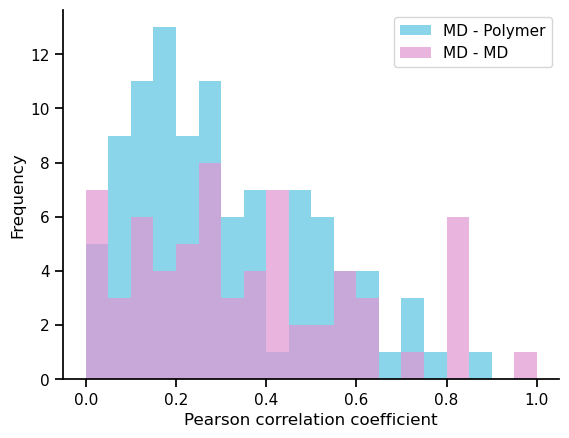

In [40]:
ax = pd.Series(md_p_corr_coeffs.values()).abs().plot.hist(bins=np.arange(0, 1.01, 0.05),
                                                color="#5ac4e2",
                                                alpha=0.7,
                                                          label="MD - Polymer",
                                               )
pd.Series(md_corr_coeffs.values()).abs().plot.hist(bins=np.arange(0, 1.01, 0.05),
                                                color="#e196d1",
                                                alpha=0.7,
                                                          label="MD - MD",
                                                          ax=ax
                                               )

ax.legend()
ax.set_xlabel("Pearson correlation coefficient")

ax.spines[['right', 'top']].set_visible(False)

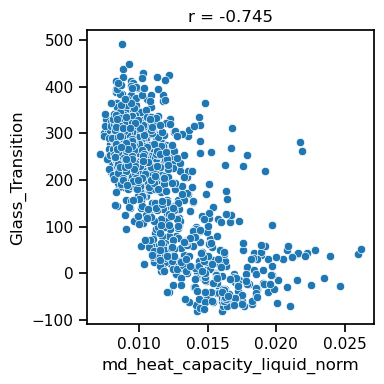

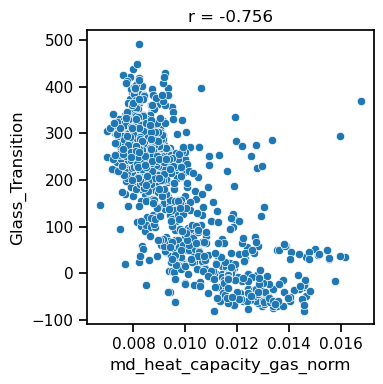

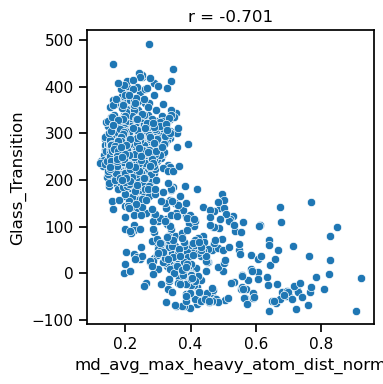

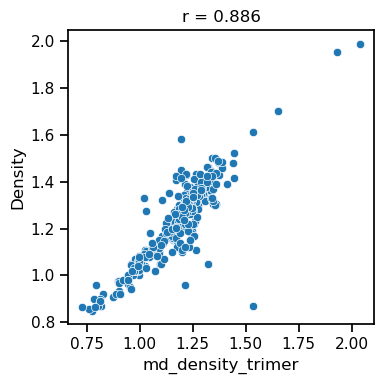

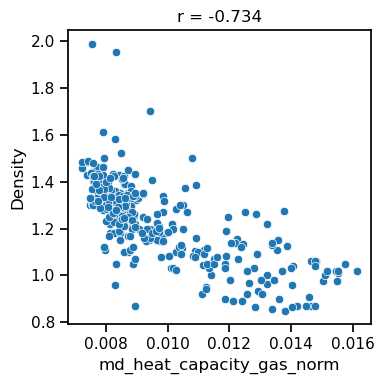

In [46]:
# plot a few of the strongest correlations
for (poly_prop, md_prop), r in strong_corr.items():
    df = data_merged[[poly_prop, md_prop]].dropna()
    plt.figure(figsize=(4, 4))
    sns.scatterplot(data=df, x=md_prop, y=poly_prop)
    plt.title(f"r = {r:0.3f}")
    # plt.xlabel(full_names.get(md_prop, md_prop))
    # plt.ylabel(full_names.get(poly_prop, poly_prop))
    plt.tight_layout()
    plt.show()